## 1. 环境准备

导入必要的库并配置中文字体支持。

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import joblib
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
from matplotlib import rcParams

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
def config_fonts():
    try:
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


# 2. 支持向量机 (SVM) 实战：鸢尾花分类

本示例展示了如何使用 scikit-learn 库中的支持向量机 (SVM) 对经典的鸢尾花 (Iris) 数据集进行分类。

### 教学目标：
1. **数据准备**：加载数据、划分训练集和测试集。
2. **数据分析**：使用箱线图观察特征分布。
3. **数据预处理**：标准化特征 (SVM 对特征尺度敏感)。
4. **模型训练**：构建并训练 SVM 分类器。
5. **模型评估**：通过混淆矩阵和分类报告评估模型性能。
6. **结果可视化**：使用 PCA 降维技术可视化决策边界。


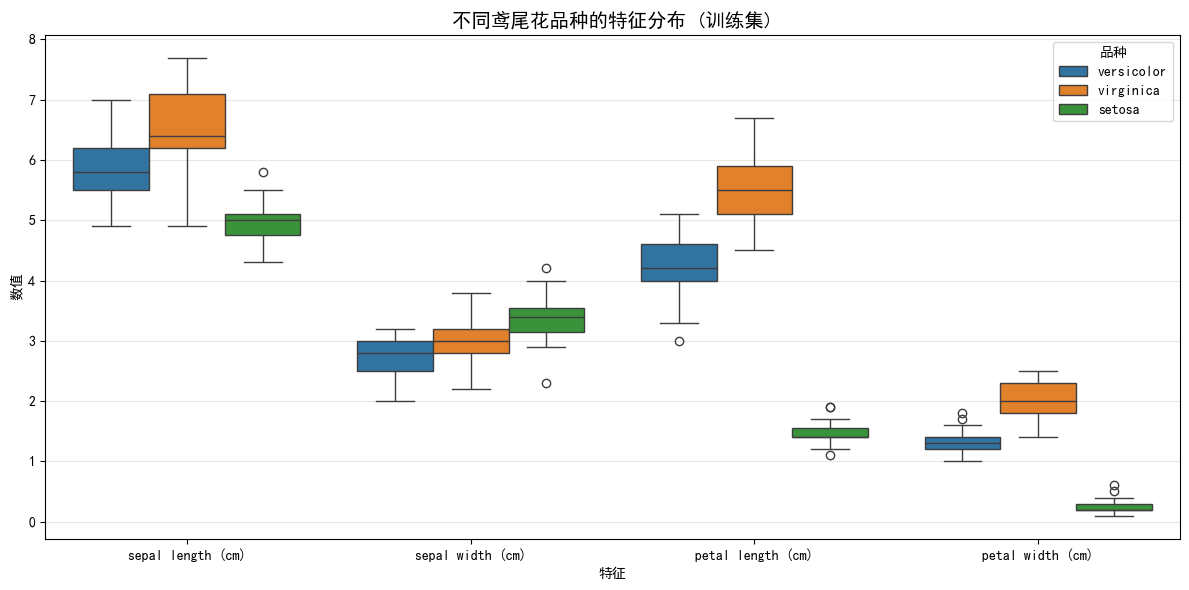

<Figure size 800x600 with 0 Axes>

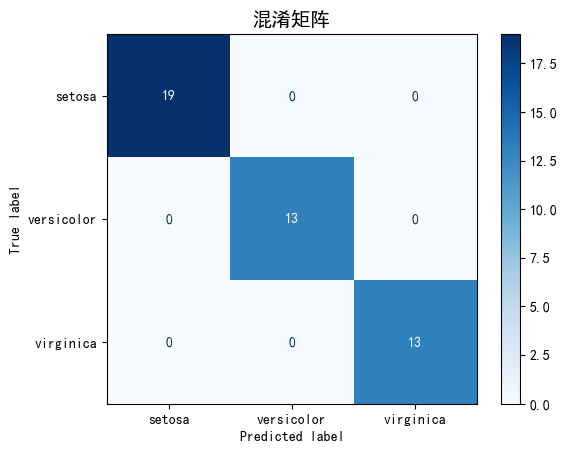

准确率 (Accuracy): 1.0000

详细分类报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



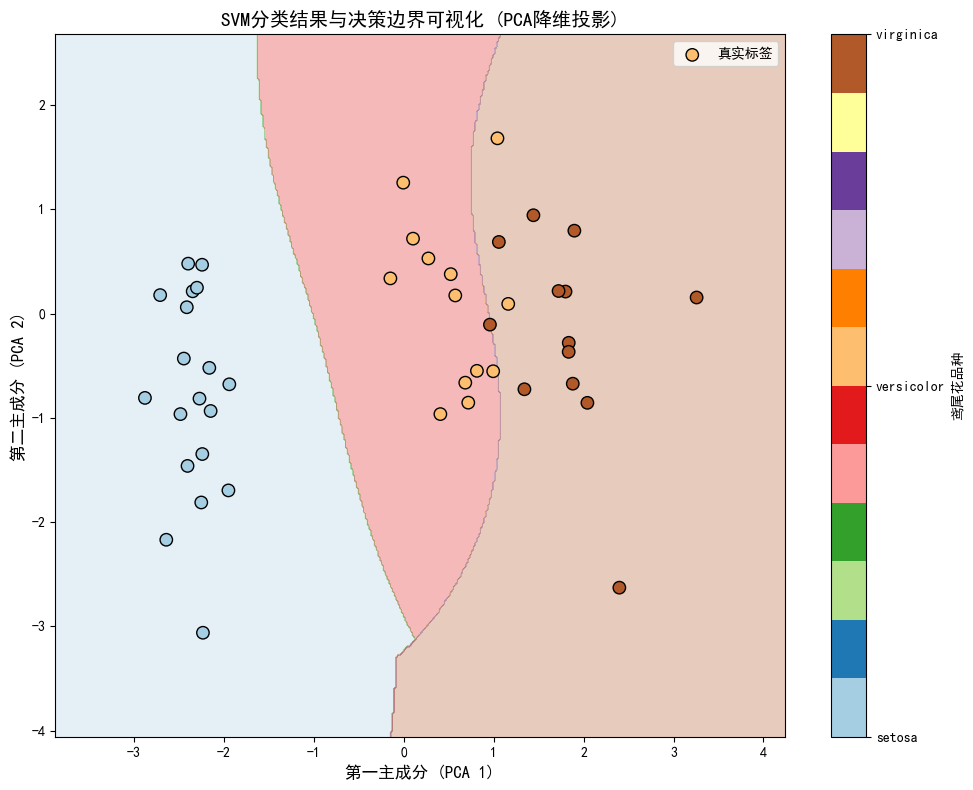

In [79]:
# ================== 1. 数据准备 ==================
# 加载鸢尾花(Iris)数据集
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

# 数据集划分：70% 训练集，30% 测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ================== 2. 数据探索性分析 (EDA) ==================
plt.figure(figsize=(12, 6))
df_train = pd.DataFrame(X_train, columns=feature_names)
df_train["品种"] = [target_names[i] for i in y_train]
melt_df = df_train.melt(id_vars="品种", var_name="特征", value_name="数值")

plt.title("不同鸢尾花品种的特征分布 (训练集)", fontsize=14)
sns.boxplot(x="特征", y="数值", hue="品种", data=melt_df)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ================== 3. 特征工程 ==================
# 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================== 4. 模型训练 ==================
# 使用 RBF 核
model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# ================== 5. 模型评估 ==================
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=target_names, cmap="Blues"
)
plt.title("混淆矩阵", fontsize=14)
plt.show()

print(f"准确率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\n详细分类报告:")
print(classification_report(y_test, y_pred, target_names=target_names))

# ================== 6. 结果可视化 (PCA降维) ==================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model_pca = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
model_pca.fit(X_train_pca, y_train)

x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolors="k", cmap=plt.cm.Paired, s=80, label="真实标签")

errors = np.where(y_pred != y_test)[0]
if len(errors) > 0:
    plt.scatter(X_test_pca[errors, 0], X_test_pca[errors, 1], s=150, edgecolors="red", facecolors="none", linewidths=2, label="分类错误", zorder=10)

plt.xlabel("第一主成分 (PCA 1)", fontsize=12)
plt.ylabel("第二主成分 (PCA 2)", fontsize=12)
plt.title("SVM分类结果与决策边界可视化 (PCA降维投影)", fontsize=14)
plt.legend(loc='upper right')
formatter = plt.FuncFormatter(lambda x, loc: target_names[int(x)] if 0 <= x < len(target_names) else '')
plt.colorbar(scatter, ticks=[0, 1, 2], label="鸢尾花品种", format=formatter)
plt.tight_layout()
plt.show()


# 3. 超参数调优 (GridSearchCV)

SVM 的性能高度依赖于超参数的选择，特别是 **C** (惩罚系数) 和 **gamma** (核函数系数)。

- **C**: 控制错误分类的惩罚力度。C 越大，试图将所有训练样本分类正确（可能导致过拟合）；C 越小，容忍更多错误分类以获得更大的间隔（泛化能力更强）。
- **gamma**: 控制 RBF 核的“影响范围”。gamma 越大，单个样本影响范围越小（容易过拟合）；gamma 越小，影响范围越广（容易欠拟合）。

我们将使用 `GridSearchCV` 配合 `Pipeline` 来寻找最佳参数组合。

In [80]:
from sklearn.model_selection import GridSearchCV

# 1. 准备数据
# 由于 sklearn 版本兼容性问题，这里暂时不使用 Pipeline，而是直接使用已标准化的数据。
# 注意：这在理论上会引入轻微的数据泄漏（验证集参与了标准化参数计算），但在教学示例中差异可忽略。
# 在生产环境中，建议使用 Pipeline 以避免任何数据泄漏。

# 2. 定义参数网格
# 注意：没有使用 Pipeline，所以参数前缀不需要 'svm__'
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto']
}

# 3. 执行网格搜索
# 直接对标准化后的训练集进行网格搜索
# 修复：使用 threading 后端避免容器环境中的多进程 pickle 版本不一致问题
with joblib.parallel_backend('threading'):
    grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, n_jobs=2, verbose=1)
    grid_search.fit(X_train_scaled, y_train)

# 4. 输出结果
print("最佳参数组合:", grid_search.best_params_)
print("最佳交叉验证得分: {:.4f}".format(grid_search.best_score_))

# 5. 使用最佳模型在测试集上评估
best_model = grid_search.best_estimator_
# 注意：测试集也需要使用相同的 scaler 进行标准化（已在前面步骤完成：X_test_scaled）
test_acc = best_model.score(X_test_scaled, y_test)
print("测试集准确率: {:.4f}".format(test_acc))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
最佳参数组合: {'C': 1, 'gamma': 0.1}
最佳交叉验证得分: 0.9524
测试集准确率: 1.0000


# 4. SVM 最大间隔原理可视化

本示例直观地展示了 SVM 的核心概念：**最大间隔**(Max Margin)。

### 核心概念：
- **决策边界**(实线)：区分不同类别的分界线。
- **支持向量**(绿色圈出)：距离决策边界最近的那些数据点。它们决定了决策边界的位置。
- **间隔**(Margin)：两条虚线之间的距离。SVM 的目标就是最大化这个间隔，从而提高模型的泛化能力。
- **硬间隔**(Hard Margin)：要求所有样本都被正确分类，且都在间隔边界之外（适用于线性可分数据）。


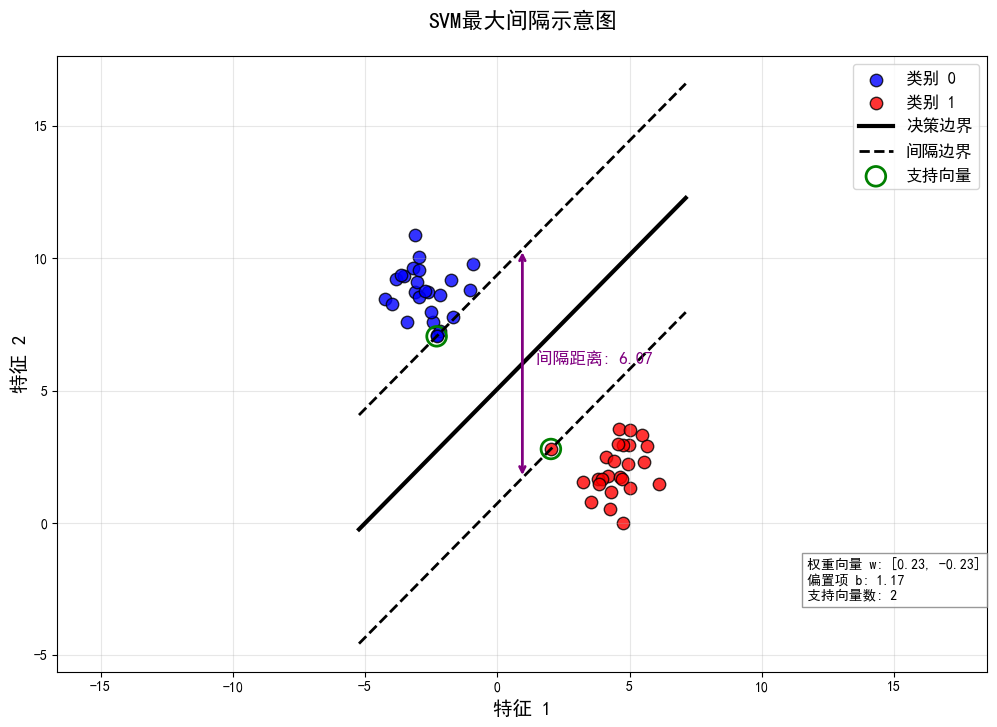

SVM模型信息:
权重向量 w: [ 0.23474325 -0.23143308]
偏置项 b: 1.1727
支持向量数量: 2
最大间隔距离: 6.0671
分类准确率: 1.0000


In [81]:
# 创建可线性分离的数据
X_blob, y_blob = make_blobs(n_samples=50, centers=2, random_state=42, cluster_std=1.0)

# 训练SVM模型 (使用线性核和大C值以模拟硬间隔)
model_linear = SVC(kernel='linear', C=1000)
model_linear.fit(X_blob, y_blob)

# 获取决策边界和间隔边界
w = model_linear.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(X_blob[:, 0].min() - 1, X_blob[:, 0].max() + 1, 100)
yy_decision = a * xx - (model_linear.intercept_[0]) / w[1]

# 计算间隔边界
margin = 1 / np.sqrt(np.sum(model_linear.coef_ ** 2))
yy_margin_upper = a * xx - (model_linear.intercept_[0] - 1) / w[1]
yy_margin_lower = a * xx - (model_linear.intercept_[0] + 1) / w[1]

# 创建图形
plt.figure(figsize=(12, 8))

# 绘制数据点
plt.scatter(X_blob[y_blob == 0, 0], X_blob[y_blob == 0, 1], c='blue', s=80, edgecolors='k', label='类别 0', alpha=0.8)
plt.scatter(X_blob[y_blob == 1, 0], X_blob[y_blob == 1, 1], c='red', s=80, edgecolors='k', label='类别 1', alpha=0.8)

# 绘制边界
plt.plot(xx, yy_decision, 'k-', linewidth=3, label='决策边界')
plt.plot(xx, yy_margin_upper, 'k--', linewidth=2, label='间隔边界')
plt.plot(xx, yy_margin_lower, 'k--', linewidth=2)

# 标记支持向量
plt.scatter(model_linear.support_vectors_[:, 0], model_linear.support_vectors_[:, 1], 
           s=200, facecolors='none', edgecolors='green', linewidths=2, 
           label='支持向量')

# 添加间隔标注
mid_x = (X_blob[:, 0].max() + X_blob[:, 0].min()) / 2
mid_y_upper = a * mid_x - (model_linear.intercept_[0] - 1) / w[1]
mid_y_lower = a * mid_x - (model_linear.intercept_[0] + 1) / w[1]
plt.annotate('', xy=(mid_x, mid_y_upper), xytext=(mid_x, mid_y_lower),
             arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
plt.text(mid_x + 0.5, (mid_y_upper + mid_y_lower)/2, f'间隔距离: {2*margin:.2f}', 
         fontsize=12, color='purple', ha='left')

plt.xlabel('特征 1', fontsize=14)
plt.ylabel('特征 2', fontsize=14)
plt.title('SVM最大间隔示意图', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axis('equal')

# 添加说明文本框
plt.figtext(0.75, 0.2, 
            f"权重向量 w: [{w[0]:.2f}, {w[1]:.2f}]\n" 
            f"偏置项 b: {model_linear.intercept_[0]:.2f}\n" 
            f"支持向量数: {len(model_linear.support_vectors_)}",
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.show()

print("="*50)
print("SVM模型信息:")
print("="*50)
print(f"权重向量 w: {w}")
print(f"偏置项 b: {model_linear.intercept_[0]:.4f}")
print(f"支持向量数量: {len(model_linear.support_vectors_)}")
print(f"最大间隔距离: {2*margin:.4f}")
print(f"分类准确率: {accuracy_score(y_blob, model_linear.predict(X_blob)):.4f}")